# ISLES to nnUnet data format

# Importación de librerías y funciones auxiliares

In [12]:
import SimpleITK as sitk
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import shutil
import pandas as pd

In [37]:
i=397

In [9]:
input_dir = "D:/jm.rivera/ISLES24/raw_data/sub-stroke0001/ses-01/sub-stroke0001_ses-01_ncct.nii.gz"
masks_dir = "D:/jm.rivera/ISLES24/derivatives/sub-stroke0001\ses-02/sub-stroke0001_ses-02_space-ncct_lesion-msk.nii.gz"
dataset_id="AISDnISLES"
output_dir = f"D:/jm.rivera/nnUnet_data/nnUNet_raw/Dataset002_{dataset_id}/"
imagesTr = os.path.join(output_dir, "imagesTr") 
labelsTr = os.path.join(output_dir, "labelsTr")

In [10]:
os.makedirs(output_dir, exist_ok=True)
os.makedirs(imagesTr, exist_ok=True)
os.makedirs(labelsTr, exist_ok=True)

In [35]:
img_path = '0141'
original_path = f"D:/jm.rivera/ISLES24/raw_data/sub-stroke{img_path[-4:]}/ses-01/sub-stroke{img_path[-4:]}_ses-01_ncct.nii.gz"
mask_path = f"D:/jm.rivera/ISLES24/derivatives/sub-stroke{img_path[-4:]}/ses-02/sub-stroke{img_path[-4:]}_ses-02_space-ncct_lesion-msk.nii.gz"

ct = sitk.ReadImage(original_path)
mask = sitk.ReadImage(mask_path)

print(img_path)

assert(ct.GetSize() == mask.GetSize())
assert(np.allclose(ct.GetSpacing(), mask.GetSpacing()))
assert(np.allclose(ct.GetOrigin(), mask.GetOrigin()))
assert(np.allclose(ct.GetDirection(), mask.GetDirection(), atol=1e-4))

0141
(0.9938975087081011, -0.014280122572631452, -0.10938113336876515, 0.008354271873070541, 0.9984818222548, -0.05444651878923768, 0.10999067381055894, 0.05319895418187104, 0.992507604129408)
(0.9938974960281616, -0.014272110875058565, -0.10938040621509697, 0.008346125775739347, 0.9984818729124106, -0.054445309563384815, 0.10999140681655986, 0.05320015335029162, 0.9925077506008543)


In [36]:
for idx, img_path in enumerate(os.listdir("D:/jm.rivera/ISLES24/raw_data/")):

    original_path = f"D:/jm.rivera/ISLES24/raw_data/sub-stroke{img_path[-4:]}/ses-01/sub-stroke{img_path[-4:]}_ses-01_ncct.nii.gz"
    mask_path = f"D:/jm.rivera/ISLES24/derivatives/sub-stroke{img_path[-4:]}/ses-02/sub-stroke{img_path[-4:]}_ses-02_space-ncct_lesion-msk.nii.gz"

    ct = sitk.ReadImage(original_path)
    mask = sitk.ReadImage(mask_path)

    print(img_path)
    assert(ct.GetSize() == mask.GetSize())
    assert(np.allclose(ct.GetSpacing(), mask.GetSpacing(), atol=1e-4))
    assert(np.allclose(ct.GetOrigin(), mask.GetOrigin(), atol=1e-4))
    assert(np.allclose(ct.GetDirection(), mask.GetDirection(), atol=1e-4))

sub-stroke0001
sub-stroke0002
sub-stroke0003
sub-stroke0004
sub-stroke0005
sub-stroke0006
sub-stroke0007
sub-stroke0008
sub-stroke0009
sub-stroke0010
sub-stroke0011
sub-stroke0012
sub-stroke0013
sub-stroke0014
sub-stroke0015
sub-stroke0016
sub-stroke0017
sub-stroke0019
sub-stroke0020
sub-stroke0021
sub-stroke0022
sub-stroke0025
sub-stroke0026
sub-stroke0027
sub-stroke0028
sub-stroke0030
sub-stroke0033
sub-stroke0036
sub-stroke0037
sub-stroke0038
sub-stroke0040
sub-stroke0043
sub-stroke0045
sub-stroke0047
sub-stroke0048
sub-stroke0049
sub-stroke0052
sub-stroke0053
sub-stroke0054
sub-stroke0055
sub-stroke0057
sub-stroke0062
sub-stroke0066
sub-stroke0068
sub-stroke0070
sub-stroke0071
sub-stroke0073
sub-stroke0074
sub-stroke0075
sub-stroke0076
sub-stroke0077
sub-stroke0078
sub-stroke0079
sub-stroke0080
sub-stroke0081
sub-stroke0082
sub-stroke0083
sub-stroke0084
sub-stroke0085
sub-stroke0086
sub-stroke0087
sub-stroke0088
sub-stroke0089
sub-stroke0090
sub-stroke0091
sub-stroke0092
sub-stroke

In [39]:
for idx, img_path in enumerate(os.listdir(imagesTr), start=1):

    case_id = f"{dataset_id}_{idx:03d}"
    original_path = f"{imagesTr}/{img_path}"
    mask_path = os.path.join(labelsTr, f"{case_id}.nii.gz")

    ct = sitk.ReadImage(original_path)
    mask = sitk.ReadImage(mask_path)

    print(img_path)
    assert(ct.GetSize() == mask.GetSize())
    assert(np.allclose(ct.GetSpacing(), mask.GetSpacing(), atol=1e-4))
    assert(np.allclose(ct.GetOrigin(), mask.GetOrigin(), atol=1e-4))
    assert(np.allclose(ct.GetDirection(), mask.GetDirection(), atol=1e-4))

AISDnISLES_001_0000.nii.gz
AISDnISLES_002_0000.nii.gz
AISDnISLES_003_0000.nii.gz
AISDnISLES_004_0000.nii.gz
AISDnISLES_005_0000.nii.gz
AISDnISLES_006_0000.nii.gz
AISDnISLES_007_0000.nii.gz
AISDnISLES_008_0000.nii.gz
AISDnISLES_009_0000.nii.gz
AISDnISLES_010_0000.nii.gz
AISDnISLES_011_0000.nii.gz
AISDnISLES_012_0000.nii.gz
AISDnISLES_013_0000.nii.gz
AISDnISLES_014_0000.nii.gz
AISDnISLES_015_0000.nii.gz
AISDnISLES_016_0000.nii.gz
AISDnISLES_017_0000.nii.gz
AISDnISLES_018_0000.nii.gz
AISDnISLES_019_0000.nii.gz
AISDnISLES_020_0000.nii.gz
AISDnISLES_021_0000.nii.gz
AISDnISLES_022_0000.nii.gz
AISDnISLES_023_0000.nii.gz
AISDnISLES_024_0000.nii.gz
AISDnISLES_025_0000.nii.gz
AISDnISLES_026_0000.nii.gz
AISDnISLES_027_0000.nii.gz
AISDnISLES_028_0000.nii.gz
AISDnISLES_029_0000.nii.gz
AISDnISLES_030_0000.nii.gz
AISDnISLES_031_0000.nii.gz
AISDnISLES_032_0000.nii.gz
AISDnISLES_033_0000.nii.gz
AISDnISLES_034_0000.nii.gz
AISDnISLES_035_0000.nii.gz
AISDnISLES_036_0000.nii.gz
AISDnISLES_037_0000.nii.gz
A

In [38]:
isles_num = []
new_num = []
for idx, img_path in enumerate(os.listdir("D:/jm.rivera/ISLES24/raw_data/"), start=1):

    original_path = f"D:/jm.rivera/ISLES24/raw_data/sub-stroke{img_path[-4:]}/ses-01/sub-stroke{img_path[-4:]}_ses-01_ncct.nii.gz"
    mask_path = f"D:/jm.rivera/ISLES24/derivatives/sub-stroke{img_path[-4:]}/ses-02/sub-stroke{img_path[-4:]}_ses-02_space-ncct_lesion-msk.nii.gz"
    case_id = f"{dataset_id}_{(idx+i):03d}"

    shutil.copy(original_path, os.path.join(imagesTr, f"{case_id}_0000.nii.gz"))
    shutil.copy(mask_path, os.path.join(labelsTr, f"{case_id}.nii.gz"))
    
    isles_num.append(img_path[-4:])
    new_num.append(f"{(idx+i):03d}")

In [13]:
index_relationship = pd.DataFrame.from_dict(data={
    "AISD Acc Num":isles_num,
    "nnUNet num" : new_num
})
index_relationship.head()

,AISD Acc Num,nnUNet num
0,0001,397
1,0002,398
2,0003,399
3,0004,400
4,0005,401


# Visual confirmation of masks alignment

In [20]:
def apply_window(image, wl, ww):
    lower = wl - ww / 2
    upper = wl + ww / 2
    windowed = np.clip(image, lower, upper)
    return windowed

Showing slice 38 (largest lesion area)


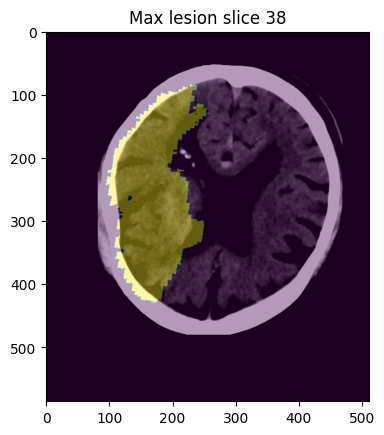

In [42]:
index = '411'

wl = 40
ww = 40

ct_image = sitk.ReadImage(os.path.join(imagesTr, f'{dataset_id}_{index}_0000.nii.gz'))
mask_image = sitk.ReadImage(os.path.join(labelsTr, f'{dataset_id}_{index}.nii.gz'))

ct_np = sitk.GetArrayFromImage(ct_image)      # (z,y,x)
mask_np = sitk.GetArrayFromImage(mask_image)  # (z,y,x)

# Find slices containing lesion
lesion_area_per_slice = mask_np.sum(axis=(1,2))
z = np.argmax(lesion_area_per_slice)
windowed_slice = apply_window(ct_np[z], wl, ww)

if lesion_area_per_slice[z] == 0:
    print("⚠️ Empty mask")
else:
    print(f"Showing slice {z} (largest lesion area)")
    
    plt.imshow(windowed_slice, cmap="gray")
    plt.imshow(mask_np[z], alpha=0.4)
    plt.title(f"Max lesion slice {z}")
    plt.show()

Showing slice 30 (largest lesion area)


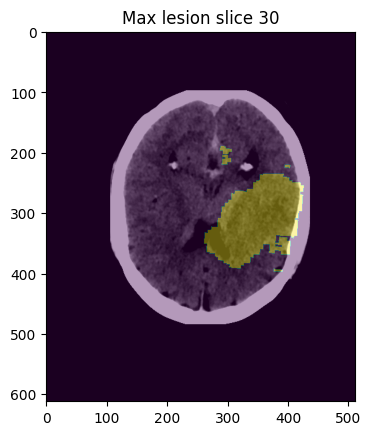

In [29]:
index = '420'

wl = 40
ww = 40

ct_image = sitk.ReadImage(os.path.join(imagesTr, f'{dataset_id}_{index}_0000.nii.gz'))
mask_image = sitk.ReadImage(os.path.join(labelsTr, f'{dataset_id}_{index}.nii.gz'))

ct_np = sitk.GetArrayFromImage(ct_image)      # (z,y,x)
mask_np = sitk.GetArrayFromImage(mask_image)  # (z,y,x)

# Find slices containing lesion
lesion_area_per_slice = mask_np.sum(axis=(1,2))
z = np.argmax(lesion_area_per_slice)
windowed_slice = apply_window(ct_np[z], wl, ww)

if lesion_area_per_slice[z] == 0:
    print("⚠️ Empty mask")
else:
    print(f"Showing slice {z} (largest lesion area)")
    
    plt.imshow(windowed_slice, cmap="gray")
    plt.imshow(mask_np[z], alpha=0.4)
    plt.title(f"Max lesion slice {z}")
    plt.show()